## Event - line

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

        Date                   Event        Type  Price_Before  Price_After  \
0 1973-10-17            OPEC embargo     embargo           2.9        11.65   
1 1979-01-01      Iranian Revolution  revolution          16.0        36.00   
2 1990-08-02      Invasion of Kuwait    invasion          17.0        36.00   
3 2008-07-01   2008 Financial Crisis   financial         133.0        36.00   
4 2014-11-01        OPEC supply glut      supply          85.0        28.00   
5 2020-03-01      COVID demand crash    pandemic          55.0        19.00   
6 2022-02-24  Russia invades Ukraine    invasion          75.0       128.00   
7 2026-02-28     Operation Epic Fury         war          72.0       126.00   

                              Note  Price_Change  Price_Change_Pct  
0  Pre-embargo → post-embargo peak          8.75             301.7  
1       Pre-revolution → 1981 peak         20.00             125.0  
2      Pre-invasion → October peak         19.00             111.8  
3   Pre-cras

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_78120/4018771176.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Event', y='Price_Change_Pct', data=df, palette=colors)


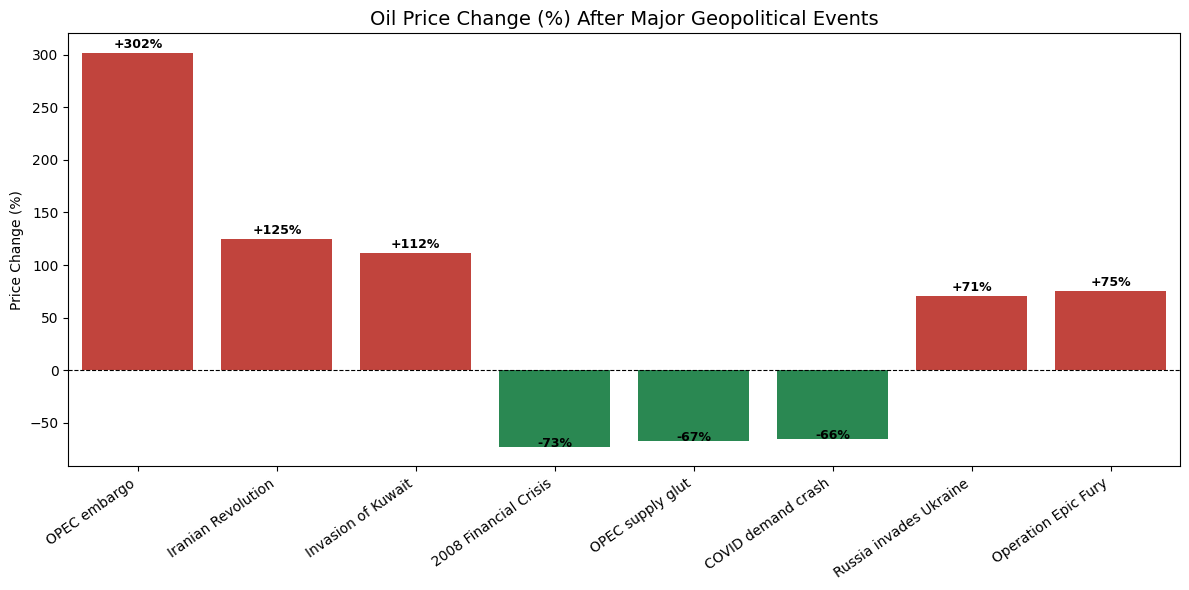

In [3]:
df = pd.DataFrame({
    'Date': [
        '1973-10-17',
        '1979-01-01',
        '1990-08-02',
        '2008-07-01',    # peak – prisen begynder at crashe herfra
        '2014-11-01',    # OPEC beslutter ikke at skære produktion → crash
        '2020-03-01',    # COVID lockdowns → demand crash
        '2022-02-24',
        '2026-02-28'
    ],
    'Event': [
        'OPEC embargo',
        'Iranian Revolution',
        'Invasion of Kuwait',
        '2008 Financial Crisis',
        'OPEC supply glut',
        'COVID demand crash',
        'Russia invades Ukraine',
        'Operation Epic Fury'
    ],
    'Type': [
        'embargo', 'revolution', 'invasion',
        'financial', 'supply', 'pandemic',
        'invasion', 'war'
    ],
    # Price_Before = pris lige FØR begivenheden
    # Price_After  = pris på det efterfølgende lavpunkt/højpunkt
    'Price_Before': [2.90,  16.00, 17.00, 133.00, 85.00, 55.00,  75.00, 72.00],
    'Price_After':  [11.65, 36.00, 36.00,  36.00, 28.00, 19.00, 128.00, 126.00],
    'Note': [
        'Pre-embargo → post-embargo peak',
        'Pre-revolution → 1981 peak',
        'Pre-invasion → October peak',
        'Pre-crash avg → post-crash low',  # rettet!
        'Pre-OPEC decision → crash low',
        'Pre-COVID → April 2020 low',
        'Pre-invasion → March 2022 peak',
        'Pre-war → March 2026 peak'
    ]
})

df['Date'] = pd.to_datetime(df['Date'])
df['Price_Change'] = df['Price_After'] - df['Price_Before']
df['Price_Change_Pct'] = ((df['Price_After'] - df['Price_Before']) / df['Price_Before'] * 100).round(1)
print(df)
plt.figure(figsize=(12, 6))

# Farv bjælkerne grøn/rød afhængigt af om prisen stiger eller falder
colors = ['#d73027' if x > 0 else '#1a9850' for x in df['Price_Change_Pct']]

bars = sns.barplot(x='Event', y='Price_Change_Pct', data=df, palette=colors)

# Tilføj værdi-labels oven på hver bjælke
for bar, val in zip(bars.patches, df['Price_Change_Pct']):
    ypos = bar.get_height() if val > 0 else bar.get_height() - 5
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        ypos + 2,
        f'{val:+.0f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Oil Price Change (%) After Major Geopolitical Events', fontsize=14)
plt.xlabel('')
plt.ylabel('Price Change (%)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

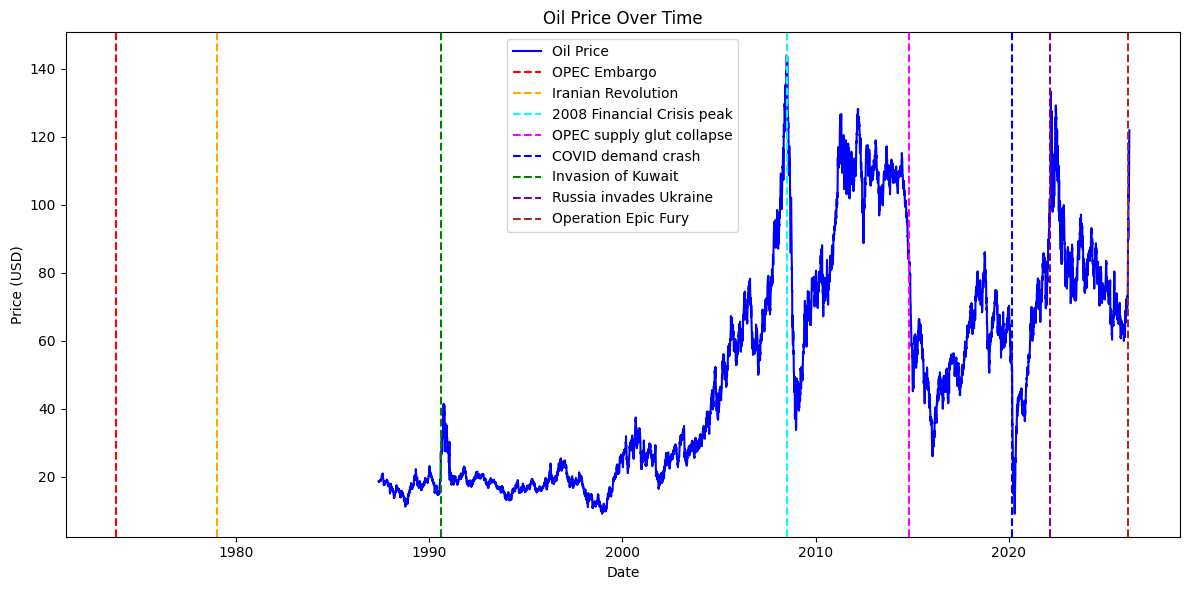

In [4]:
df_oil = pd.read_csv("/Users/sandrarune/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/8. sem/Social dataanalyse og vis/WEEKS_ny/Sandra359.github.io/FinalProject/datasæt/filtered_data.csv")
df_oil['Date'] = pd.to_datetime(df_oil['Date'])
df_oil.set_index('Date', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_oil.index, df_oil['Price'], label='Oil Price', color='blue')
plt.title('Oil Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.axvline(pd.to_datetime('1973-10-17'), color='red', linestyle='--', label='OPEC Embargo')
plt.axvline(pd.to_datetime('1979-01-01'), color='orange', linestyle='--', label='Iranian Revolution')
plt.axvline(pd.to_datetime('2008-07-01'), color='cyan', linestyle='--', label='2008 Financial Crisis peak')
plt.axvline(pd.to_datetime('2014-11-01'), color='magenta', linestyle='--', label='OPEC supply glut collapse')
plt.axvline(pd.to_datetime('2020-03-01'), color='blue', linestyle='--', label='COVID demand crash')
plt.axvline(pd.to_datetime('1990-08-02'), color='green', linestyle='--', label='Invasion of Kuwait')
plt.axvline(pd.to_datetime('2022-02-24'), color='purple', linestyle='--', label='Russia invades Ukraine')
plt.axvline(pd.to_datetime('2026-02-28'), color='brown', linestyle='--', label='Operation Epic Fury')
plt.legend()
plt.tight_layout()
plt.show()